In [0]:
from pyspark.sql.functions import *
import matplotlib.pyplot as plt


In [0]:
import matplotlib
print(matplotlib.__version__)

3.10.0


In [0]:
appointments_data = [
(1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
(1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
(1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
(1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
(1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
(1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
(1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
(1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
(1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
(1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
(1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
(1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
(1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
(1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
(1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]
columns = [
"appointment_id",
"city",
"department",
"hospital",
"consultation_fee",
"status"
]

df = spark.createDataFrame(appointments_data, columns)
display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


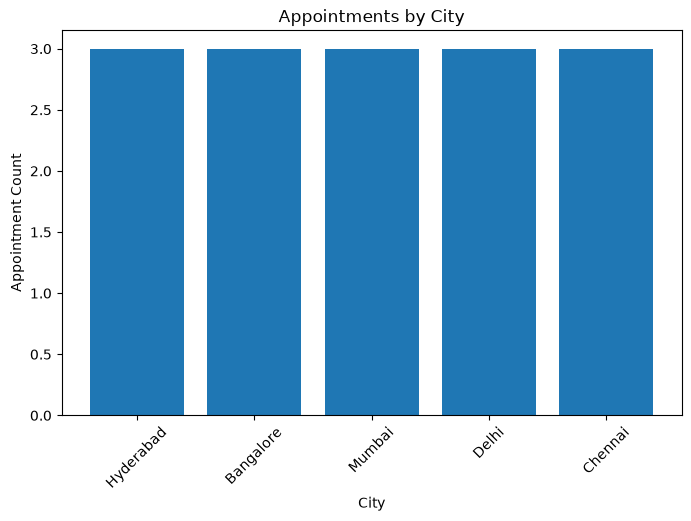

In [0]:
city_count_df = df.groupBy("city").agg(
    count("appointment_id").alias("total_appointments")
)

city_pd = city_count_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_pd["city"], city_pd["total_appointments"])
plt.xlabel("City")
plt.ylabel("Appointment Count")
plt.title("Appointments by City")
plt.xticks(rotation=45)
plt.show()

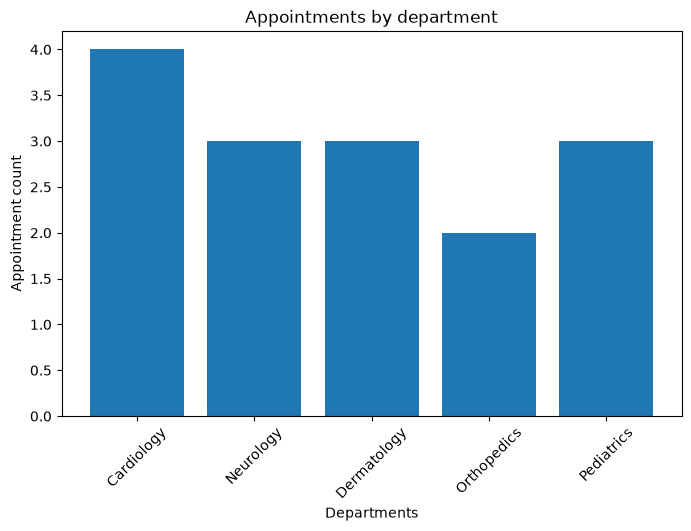

In [0]:
dept_df=df.groupBy("department").agg(
    count("appointment_id").alias("total_appointments")
)

dept_pd=dept_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_pd["department"],dept_pd["total_appointments"])
plt.xlabel("Departments")
plt.ylabel("Appointment count")
plt.title("Appointments by department")
plt.xticks(rotation=45)
plt.show()

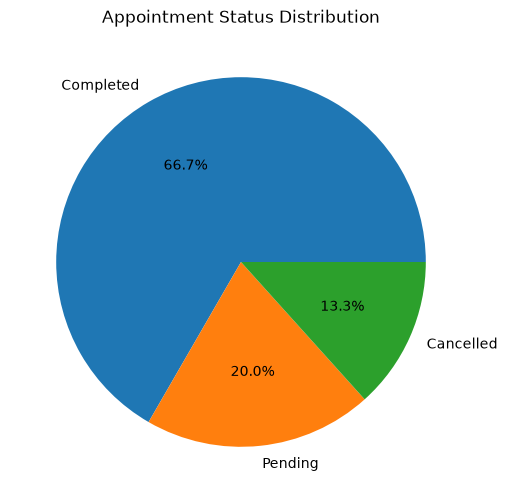

In [0]:
status_df = df.groupBy("status").agg(
    count("appointment_id").alias("count")
)

status_pd = status_df.toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title("Appointment Status Distribution")
plt.show()

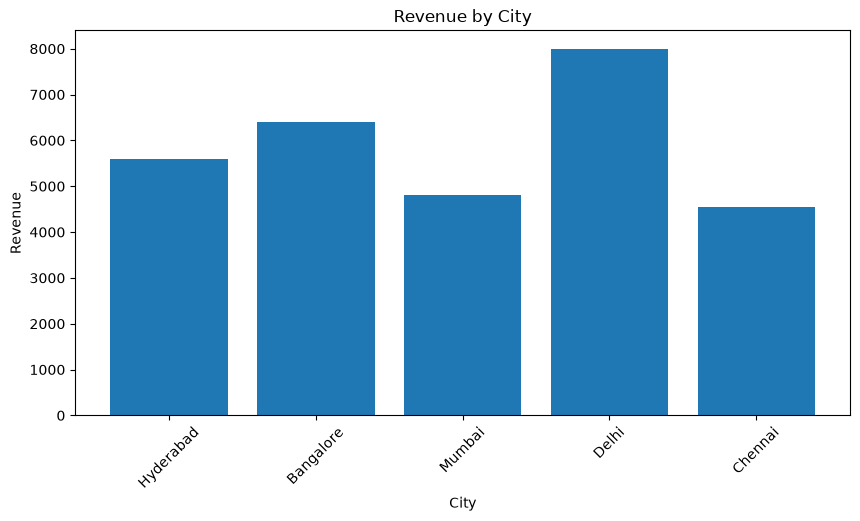

In [0]:
city_revenue_df = df.groupBy("city").agg(
    sum("consultation_fee").alias("total_revenue")
)

city_pd = city_revenue_df.toPandas()

plt.figure(figsize=(10,5))
plt.bar(city_pd["city"], city_pd["total_revenue"])
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

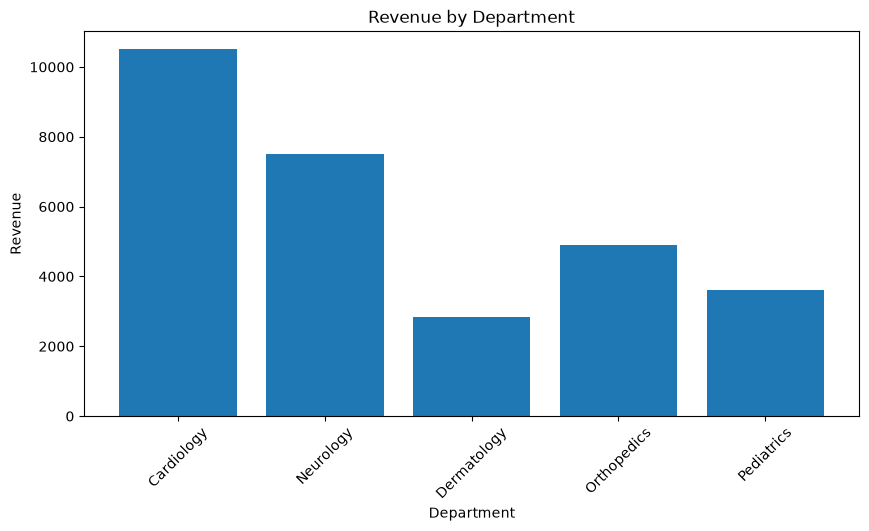

In [0]:
dept_revenue_df = df.groupBy("department").agg(
    sum("consultation_fee").alias("total_revenue")
)

dept_pd = dept_revenue_df.toPandas()

plt.figure(figsize=(10,5))
plt.bar(dept_pd["department"], dept_pd["total_revenue"])
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.title("Revenue by Department")
plt.xticks(rotation=45)
plt.show()

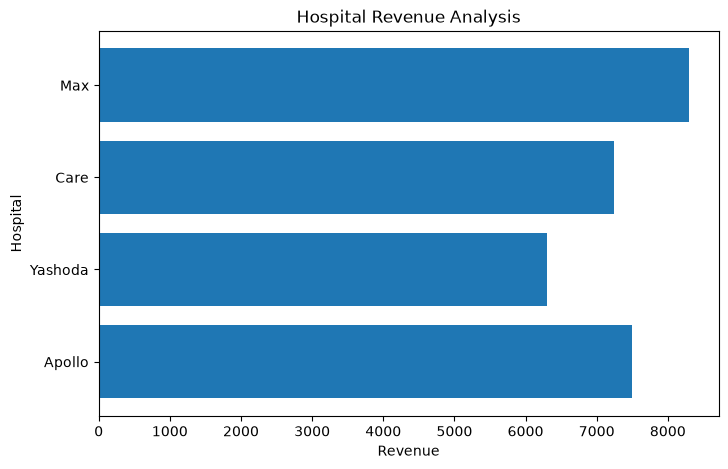

In [0]:

hospital_df = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("total_revenue")
)

hospital_pd = hospital_df.toPandas()

plt.figure(figsize=(8,5))
plt.barh(
    hospital_pd["hospital"],
    hospital_pd["total_revenue"]
)
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.title("Hospital Revenue Analysis")
plt.show()

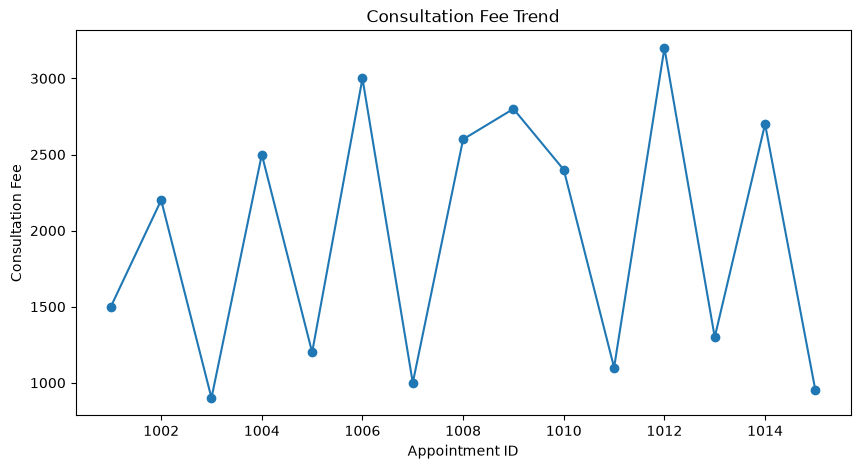

In [0]:
fee_pd = df.orderBy("appointment_id").toPandas()

plt.figure(figsize=(10,5))
plt.plot(
    fee_pd["appointment_id"],
    fee_pd["consultation_fee"],
    marker="o"
)
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.title("Consultation Fee Trend")
plt.show()

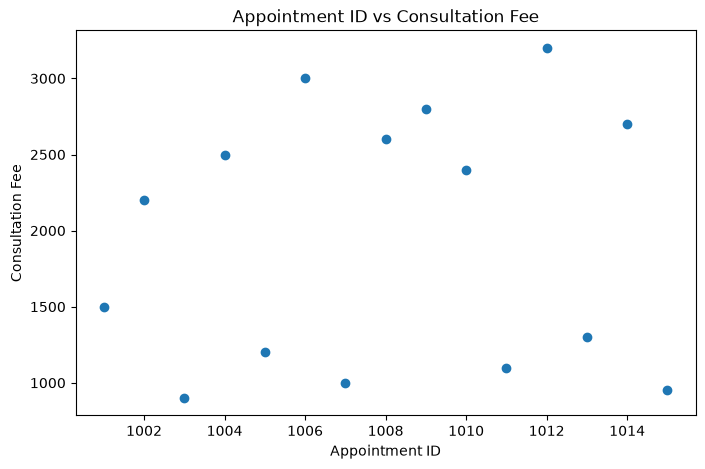

In [0]:
scatter_pd = df.toPandas()

plt.figure(figsize=(8,5))
plt.scatter(
    scatter_pd["appointment_id"],
    scatter_pd["consultation_fee"]
)
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.title("Appointment ID vs Consultation Fee")
plt.show()

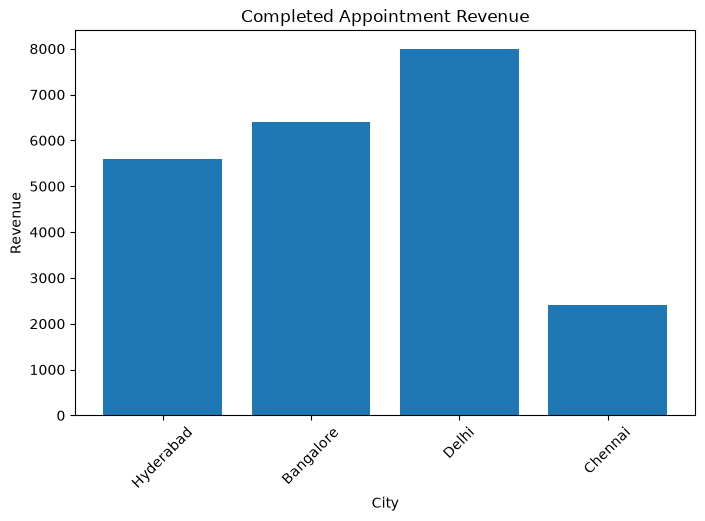

In [0]:
completed_df = df.filter(col("status")=="Completed")

completed_city_df = completed_df.groupBy("city").agg(
    sum("consultation_fee").alias("revenue")
)

completed_pd = completed_city_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    completed_pd["city"],
    completed_pd["revenue"]
)
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Completed Appointment Revenue")
plt.xticks(rotation=45)
plt.show()

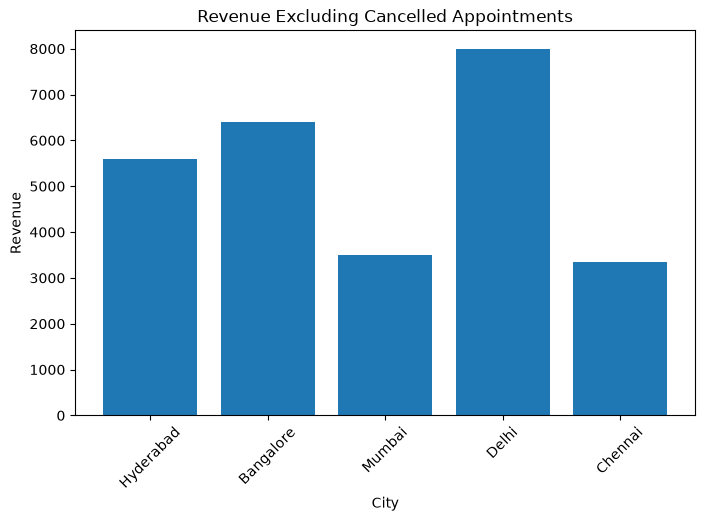

In [0]:
revenue_df = df.filter(col("status")!="Cancelled")

city_df = revenue_df.groupBy("city").agg(
    sum("consultation_fee").alias("revenue")
)

city_pd = city_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    city_pd["city"],
    city_pd["revenue"]
)
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue Excluding Cancelled Appointments")
plt.xticks(rotation=45)
plt.show()

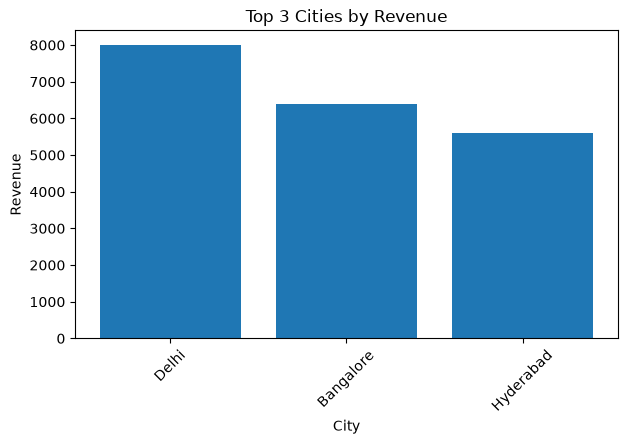

In [0]:
top_city_df = df.groupBy("city").agg(
    sum("consultation_fee").alias("revenue")
).orderBy(col("revenue").desc()).limit(3)

top_city_pd = top_city_df.toPandas()

plt.figure(figsize=(7,4))
plt.bar(
    top_city_pd["city"],
    top_city_pd["revenue"]
)
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Top 3 Cities by Revenue")
plt.xticks(rotation=45)
plt.show()

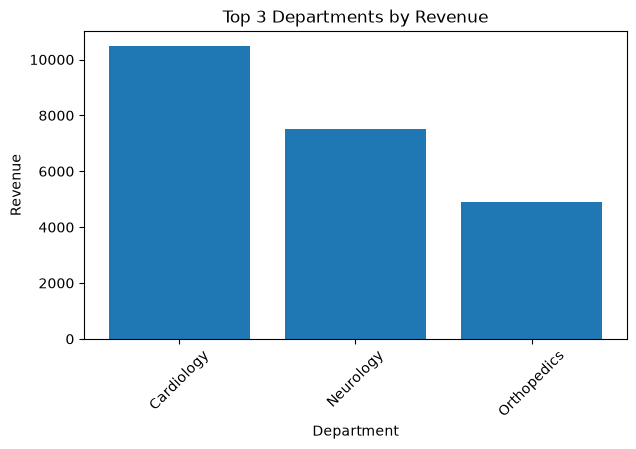

In [0]:
top_dept_df = df.groupBy("department").agg(
    sum("consultation_fee").alias("revenue")
).orderBy(col("revenue").desc()).limit(3)

top_dept_pd = top_dept_df.toPandas()

plt.figure(figsize=(7,4))
plt.bar(
    top_dept_pd["department"],
    top_dept_pd["revenue"]
)
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.title("Top 3 Departments by Revenue")
plt.xticks(rotation=45)
plt.show()

In [0]:
lowest_df = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).orderBy("revenue").limit(1)

lowest_df.show()

+--------+-------+
|hospital|revenue|
+--------+-------+
| Yashoda|   6300|
+--------+-------+



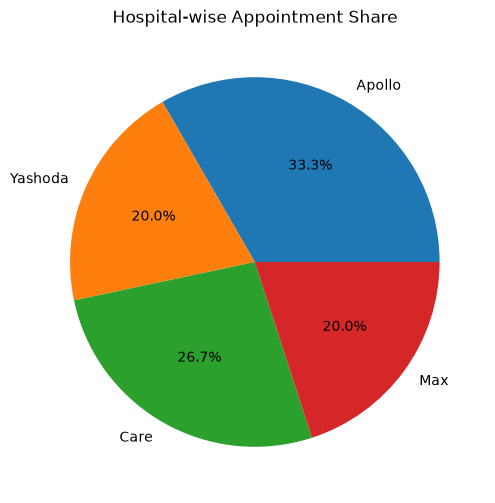

In [0]:
hospital_df = df.groupBy("hospital").agg(
    count("appointment_id").alias("appointments")
)

hospital_pd = hospital_df.toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    hospital_pd["appointments"],
    labels=hospital_pd["hospital"],
    autopct="%1.1f%%"
)
plt.title("Hospital-wise Appointment Share")
plt.show()

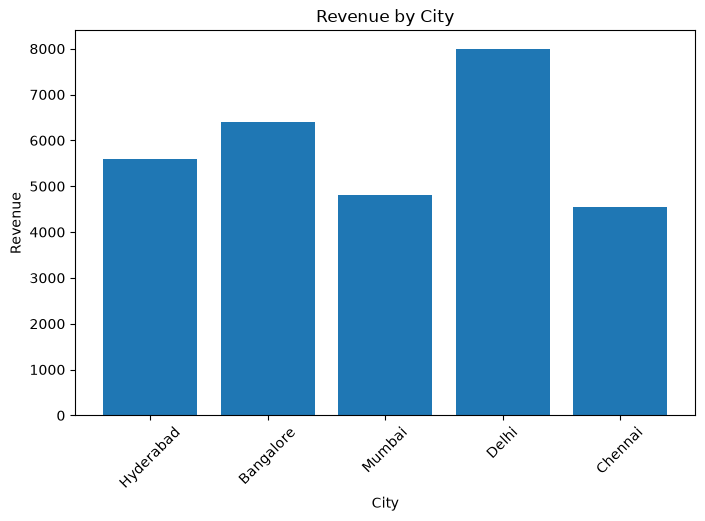

In [0]:
city_revenue_df = df.groupBy("city").agg(
    sum("consultation_fee").alias("total_revenue")
)

city_pd = city_revenue_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_pd["city"], city_pd["total_revenue"])
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

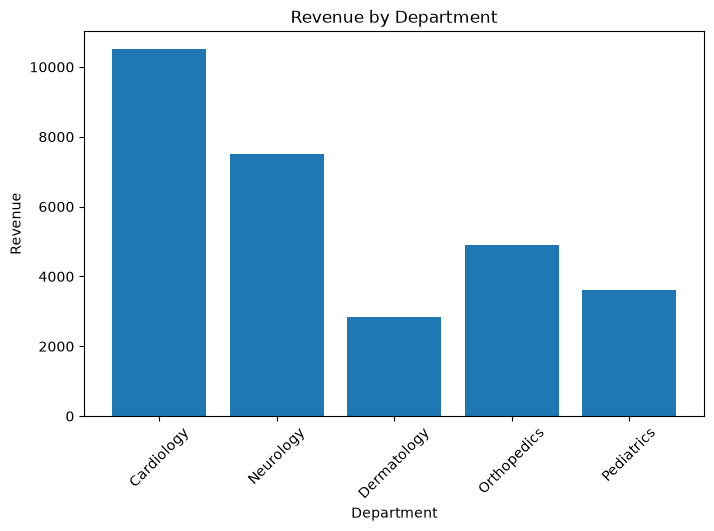

In [0]:
dept_revenue_df = df.groupBy("department").agg(
    sum("consultation_fee").alias("total_revenue")
)

dept_pd = dept_revenue_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_pd["department"], dept_pd["total_revenue"])
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.title("Revenue by Department")
plt.xticks(rotation=45)
plt.show()

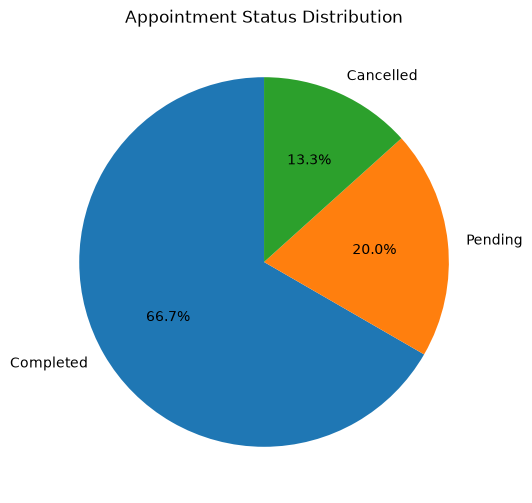

In [0]:
status_df = df.groupBy("status").agg(
    count("appointment_id").alias("count")
)

status_pd = status_df.toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Appointment Status Distribution")
plt.show()

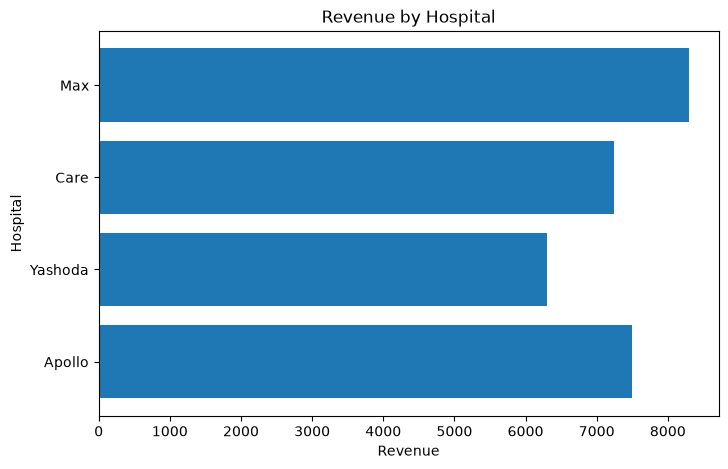

In [0]:
hospital_revenue_df = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("total_revenue")
)

hospital_pd = hospital_revenue_df.toPandas()

plt.figure(figsize=(8,5))
plt.barh(
    hospital_pd["hospital"],
    hospital_pd["total_revenue"]
)
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.title("Revenue by Hospital")
plt.show()